# Logistic Regression: Predicting Hotel Booking Cancellations

In addition to SQL and exploratory data analysis, a Logistic Regression model was developed to identify the booking characteristics most strongly associated with reservation cancellations.

Unlike SQL analysis, which examines each factor separately, Logistic Regression evaluates all variables simultaneously, allowing us to estimate the independent effect of each feature while controlling for the others.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

df = pd.read_csv(
    r"C:\Users\Kompiuteris\Downloads\hotel_bookings_cleaned.csv"
)
hotel_bookings = df

## Selecting Features

The model uses booking characteristics that are available before check-in.

The target variable is:

- **is_canceled**

The predictor variables include booking behaviour, customer characteristics and reservation details.

In [17]:
features = [
    "hotel",
    "lead_time",
    "deposit_type",
    "distribution_channel",
    "customer_type",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "total_of_special_requests",
    "adr"
]

X = df[features]

y = df["is_canceled"]

## Preparing Categorical Variables

Categorical variables are transformed using One-Hot Encoding.

Numeric variables are passed directly into the model.

In [19]:
categorical_features = [
    "hotel",
    "deposit_type",
    "distribution_channel",
    "customer_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Splitting the Dataset

The dataset is divided into training and testing sets.

A stratified split is used to preserve the original cancellation distribution.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Training the Logistic Regression Model

A Logistic Regression classifier is trained to predict whether a booking will be cancelled.

In [25]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['hotel', 'deposit_type',
                                                   'distribution_channel',
                                                   'customer_type'])])),
                ('classifier', LogisticRegression(max_iter=3000))])

## Model Evaluation

The trained model is evaluated using several classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These metrics measure how well the model distinguishes cancelled bookings from completed bookings.

In [29]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, predictions),3))
print("Precision:", round(precision_score(y_test, predictions),3))
print("Recall   :", round(recall_score(y_test, predictions),3))
print("F1 Score :", round(f1_score(y_test, predictions),3))
print("ROC AUC  :", round(roc_auc_score(y_test, probabilities),3))

Accuracy : 0.789
Precision: 0.878
Recall   : 0.505
F1 Score : 0.641
ROC AUC  : 0.82


## Feature Importance

The Logistic Regression coefficients are extracted to evaluate how each booking characteristic influences cancellation probability.

Positive coefficients indicate an increased likelihood of cancellation.

Negative coefficients indicate characteristics associated with more reliable bookings.

Odds Ratios are also calculated to simplify interpretation.

In [31]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

importance = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients

})

importance["Odds Ratio"] = np.exp(

    importance["Coefficient"]

)

In [32]:
importance["Effect"] = np.where(

    importance["Coefficient"] > 0,

    "Increases Cancellation Risk",

    "Reduces Cancellation Risk"

)

importance["Absolute Coefficient"] = importance[
    "Coefficient"
].abs()

importance = importance.sort_values(
    "Absolute Coefficient",
    ascending=False
)

importance

,Feature,Coefficient,Odds Ratio,Effect,Absolute Coefficient
1,cat__deposit_type_Non Refund,4.750527,115.645270,Increases Cancellation Risk,4.750527
12,remainder__previous_cancellations,2.701586,14.903347,Increases Cancellation Risk,2.701586
8,cat__customer_type_Transient,1.167318,3.213363,Increases Cancellation Risk,1.167318
11,remainder__is_repeated_guest,-0.675280,0.509014,Reduces Cancellation Risk,0.675280
15,remainder__total_of_special_requests,-0.583183,0.558119,Reduces Cancellation Risk,0.583183
13,remainder__previous_bookings_not_canceled,-0.540785,0.582291,Reduces Cancellation Risk,0.540785
3,cat__distribution_channel_Direct,-0.488444,0.613581,Reduces Cancellation Risk,0.488444
5,cat__distribution_channel_TA/TO,0.452201,1.571767,Increases Cancellation Risk,0.452201
4,cat__distribution_channel_GDS,-0.442023,0.642735,Reduces Cancellation Risk,0.442023
14,remainder__booking_changes,-0.385459,0.680138,Reduces Cancellation Risk,0.385459


## Visualising Feature Importance

The following chart ranks booking characteristics according to the magnitude of their Logistic Regression coefficients.

Features located on the right increase cancellation probability, while those on the left reduce cancellation probability.

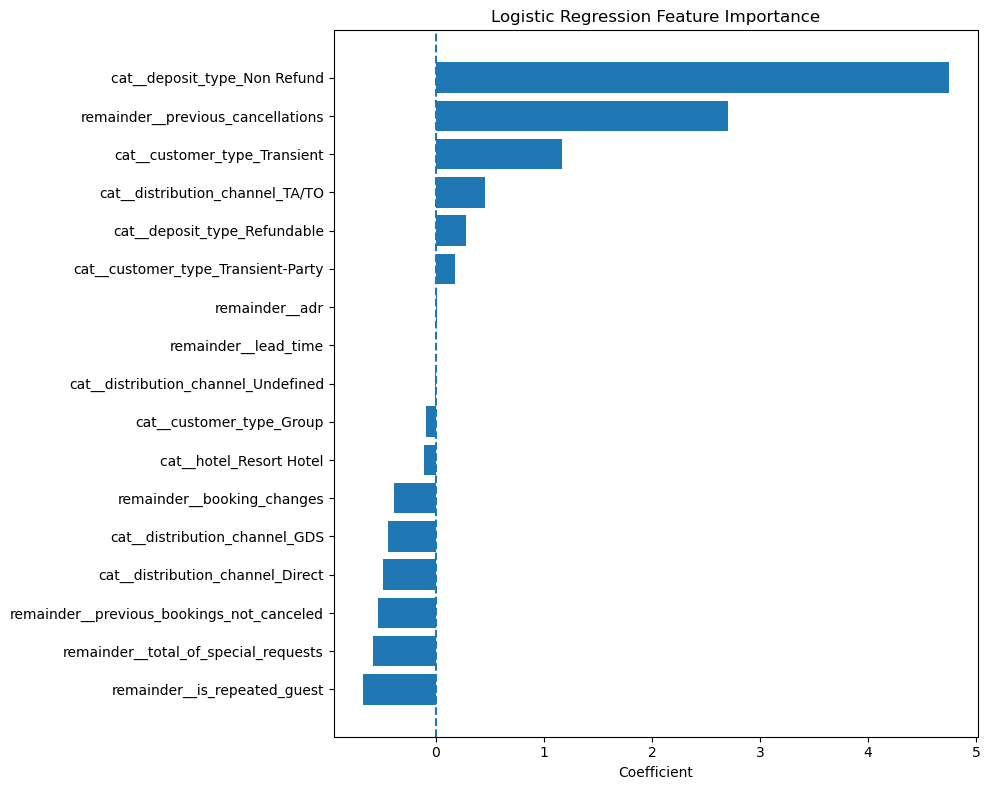

In [34]:
plot = importance.sort_values("Coefficient")

plt.figure(figsize=(10,8))

plt.barh(
    plot["Feature"],
    plot["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Logistic Regression Feature Importance")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

In [35]:
importance["Feature"] = importance["Feature"].replace({

    "cat__deposit_type_Non Refund": "Non Refund Deposit",

    "cat__deposit_type_Refundable": "Refundable Deposit",

    "cat__distribution_channel_Direct": "Direct Channel",

    "cat__distribution_channel_GDS": "GDS Channel",

    "cat__distribution_channel_TA/TO": "TA/TO Channel",

    "cat__distribution_channel_Undefined": "Undefined Channel",

    "cat__customer_type_Transient": "Transient Customer",

    "cat__customer_type_Transient-Party": "Transient Party",

    "cat__customer_type_Group": "Group Customer",

    "cat__hotel_Resort Hotel": "Resort Hotel",

    "remainder__lead_time": "Lead Time",

    "remainder__previous_cancellations": "Previous Cancellations",

    "remainder__previous_bookings_not_canceled": "Previous Successful Bookings",

    "remainder__booking_changes": "Booking Changes",

    "remainder__is_repeated_guest": "Repeat Guest",

    "remainder__total_of_special_requests": "Special Requests",

    "remainder__adr": "Average Daily Rate"

})

In [36]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'json', 'getpass', 'hashlib', 'import_pandas_safely', '__pandas', 'is_data_frame', 'dataframe_columns', 'dtypes_str', 'dataframe_hash', 'get_dataframes', '_2', '_i3', '_3', '_i4', '_4', '_i5', '_i6', '_6', '_i7', '_i8', '_8', '_i9', '_i10', '_10', '_i11', '_i12', '_12', '_i13', '_i14', '_14', '_i15', 'pd', 'np', 'plt', 'ColumnTransformer', 'OneHotEncoder', 'Pipeline', 'LogisticRegression', 'train_test_split', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'df', 'hotel_bookings', '_i16', '_16', '_i17', 'features', 'X', 'y', '_i18', '_18', '_i19', 'categorical_features', 'preprocessor', '_i20', '_20', '_i21', 'X_train', 'X_test', 'y_train', 'y_test', '_i22', '_22', '_i23', '_23', '_i24', '_24', '_i25', 'model',

In [43]:
importance.to_csv(
    r"C:\Users\Kompiuteris\Downloads\Feature_Importance.csv",
    index=False
)

print("Feature Importance exported successfully!")

Feature Importance exported successfully!
